# Edge Keyword Spotting (KWS) with SSM on Pico — 12-Class (SC12)

This notebook is an **educational demo** showing how a **State Space Model (SSM)**–based  TENNs keyword spotting model runs on **Pico**, BrainChip's FPGA hardware, for efficient inference at the edge.

**What you'll see:**
- **Model:** `tenn_recurrent_sc12` — an SSM (kernelized state-space) model for the **Speech Commands v0.02 (SC12)** dataset (10 keywords + silence + unknown).
- **Streaming:** The model is converted to a **stateful**, chunk-based form so it can process audio in small steps (e.g. 256 samples), matching real-time use.
- **Hardware:** After quantization, the model is converted to the Akida format and mapped onto the Pico FPGA, enabling efficient execution on a 50 MHz FPGA clock. On an ASIC, performance would be significantly higher, and the numbers can be scaled accordingly.

**Run cells in order.** The pipeline flows: data → model → stateful conversion → quantization → Pico deployment → streaming inference. Some sections depend on earlier ones: power estimates use `m` from the latency cell; the streaming demo and optional eval require `model_akida`, `X_test`, and `y_test` from prior cells.

## Overview

**What this demo does:** This notebook runs a **State Space Model (SSM)** keyword-spotting (KWS) model on **Pico**: load the pre-trained model → convert it to a **stateful**, chunk-based form for streaming → **quantize** to int8/int16 → **map** to Akida/Pico → run **frame-by-frame inference** on device.

**What Pico is:** Pico is BrainChip's **FPGA-based hardware** for edge inference: low latency, low power, and capable of running quantized neural models (including SSMs) in real time.

- **Why this matters for Pico:** The entire pipeline is designed so the model can run *on* Pico in a streaming fashion—stateful conversion, quantization, and mapping are all required for that.
- **What you should see:** After running the notebook, inference executes on the device and you get keyword predictions (and optionally latency/FPS metrics).

## 1. Imports

We use **akida** (runtime for Pico), **akida_models** (SSM KWS model), **quantizeml** (quantization), and **cnn2snn** (convert to Akida). Helpers for data loading, streaming inference, and plotting live in `kws_utils.py` so the notebook stays focused on the pipeline.

In [1]:
import os
# Suppress TensorFlow warnings for cleaner output
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import akida
import numpy as np
import tensorflow as tf
from cnn2snn import convert
import akida_models

from kws_utils import (
    sliding_mean,
    softmax,
    plot_streaming_demo,
    # plot_ground_truth_logit_streaming,
    plot_streaming_debug,
    plot_power_estimates,
    plot_duty_cycle_explanation,
    plot_latency_vs_clock,
    plot_power_vs_clock,
    plot_throughput_vs_clock,
    LABEL_NAMES,
    SAMPLE_RATE,
)
import matplotlib.pyplot as plt


E0000 00:00:1784249860.234881  697528 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784249860.238065  697528 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784249860.246369  697528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784249860.246384  697528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784249860.246386  697528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784249860.246387  697528 computation_placer.cc:177] computation placer already registered. Please check linka

## Data: what audio frames look like

**Glossary**
- **Sample rate:** Number of samples per second (here: **16 kHz**). One second of audio = 16,000 samples; each clip here is **16,384** samples (2¹⁴, ≈1.02 s).
- **Frame length:** Length of one full clip in samples. Here **16,384** (2¹⁴ samples, ≈1.02 s at 16 kHz). Each test example is one frame.
- **Hop (timestep):** In streaming, the number of **new** samples per step. Here **256** — each forward pass consumes 256 samples; state carries context across hops.
- **Labels:** Integer class IDs **0–11** for the 12 Speech Commands (SC12) classes: down(0), go(1), left(2), no(3), off(4), on(5), right(6), stop(7), up(8), yes(9), silence(10), unknown(11).

- **Why this matters for Pico:** Pico runs on small chunks (256 samples); the stateful model and this hop size must match so that streaming on device matches the converted model.
- **What you should see:** `X_test` with shape `(N, 16384, 1)`; streaming uses 256-sample chunks and the same sample rate (16 kHz).

## 2. Load test data (SC12)

Each clip is **16,384 samples** (2¹⁴, ≈1.02 s at 16 kHz). For streaming we use a **timestep of 256** samples per chunk.

This cell loads the SC12 test set from **TensorFlow Datasets** (downloads ~2 GB on first run, then cached locally to `~/tensorflow_datasets/`).

In [2]:
# Paths: BASE_DIR = folder containing this notebook and weight files.
BASE_DIR = os.getcwd()
length = 16384
timestep = 256

# Load SC12 test set from TFDS (auto-downloads on first run, ~2 GB cached locally)
from kws_utils import load_sc12_test_data
print("Loading SC12 test set from TFDS (this may take a few minutes on first run)...")
X_test, y_test = load_sc12_test_data(length=length)
print(f"Test set: {X_test.shape[0]} samples, {length} samples/clip, shape {X_test.shape}")

Loading SC12 test set from TFDS (this may take a few minutes on first run)...
Test set: 4890 samples, 16384 samples/clip, shape (4890, 16384, 1)


## Model: what an SSM is (and why it's good for streaming KWS)

**State Space Model (SSM) in 5 bullets**
1. An **SSM** maintains a **hidden state** that evolves over time as it sees the input sequence.
2. At each step it does: (current state + input) → (new state, output). So it's **recurrent**.
3. Many SSMs are implemented in **kernelized** form (efficient convolution-like view over the sequence).
4. They handle **long sequences** well without the cost of full attention.
5. They're **naturally streaming**: process one chunk, update state, pass state to the next chunk — no need to see the whole clip at once.

**Why it's good for streaming KWS:** Keyword spotting is sequential (audio over time). An SSM can process 256-sample chunks, carry state across chunks, and still approximate the full-clip result — ideal for real-time, edge deployment on Pico.

- **Why this matters for Pico:** The stateful, chunk-based SSM is what gets quantized and mapped to Pico; understanding SSMs explains why we do stateful conversion.
- **What you should see:** Model summary with `Kernelized` (SSM) layers; after stateful conversion, `StatefulRecurrent` layers and input shape `(1, 256, 1)`.

## 3. Load model and weights

The **tenn_recurrent_sc12** model is an SSM (state-space / kernelized) model for the Speech Commands SC12 dataset (10 keywords + silence + unknown). It takes raw waveform input `(batch, 16384, 1)` and outputs **12** class logits. Loading the pre-trained weights prepares it for stateful conversion and quantization.

In [3]:
model = akida_models.tenn_recurrent_sc12()

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:
Model: "tenn_recurrent_sc12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 16384, 1)]        0         
                                                                 
 rescaling (Rescaling)       (None, 16384, 1)          0         
                                                                 
 ssm_layer_0 (Kernelized)    (None, 16384, 8)          768       
                                                                 
 ssm_layer_0/downsampling (  (None, 4096, 8)           0         
 Stride)                                                         
                                                                 
 ssm_layer_0/BN (BatchNorma  (None, 4096, 8)           32        
 lization)                                                       
                                                                 
 ssm_layer_0/relu (ReLU)   

In [4]:
weights_path = os.path.join(BASE_DIR, "weights", "tenn_recurrent_sc12.h5")
if not os.path.exists(weights_path):
    raise FileNotFoundError(
        f"Weights file not found: {weights_path}\n"
        "Place tenn_recurrent_sc12.h5 in the 'weights/' subfolder next to this notebook."
    )
model.load_weights(weights_path)
print(f"✓ Loaded weights from: {weights_path}")

✓ Loaded weights from: /home/brainchip/pico/pico_fresh/bc_cloud_pico/examples/kws/weights/tenn_recurrent_sc12.h5


## Streaming: stateful conversion

**What "state" means:** The **state** is the internal memory of the model: a set of vectors (per layer) that summarize "what has been seen so far." Each time you feed a new chunk, the model updates this state and produces an output for that chunk. The next chunk uses the **updated** state, so the model effectively has context over the whole stream.

**Stateful conversion:** The original model takes the **full** sequence (e.g. 16,384 samples). **Stateful conversion** rewrites it so that:
- Input is **one chunk** (e.g. 256 samples) and optional previous state.
- Output is the chunk's output plus **new state** to feed into the next call.
- Running chunk-by-chunk with state carried between calls gives the **same** result as running the full sequence at once (up to numerics).

- **Why this matters for Pico:** Pico runs one frame at a time; stateful conversion is what makes that equivalent to the full model. Without it, you couldn't run true streaming on device.
- **What you should see:** A stateful model with input shape `(1, 256, 1)` and layers like `StatefulRecurrent` and `StatefulProjection`; no change to the number of parameters, but chunk-based interface.

## 4. Stateful conversion for streaming

For **edge deployment**, we don’t process the full 16k samples at once. We convert the model to a **stateful** version that consumes **chunks of 256 samples** and keeps an internal state between chunks. This matches how Pico runs inference in real time: one small frame at a time, with state carried across frames.

In [5]:
from akida_models.tenn_recurrent.convert_recurrent import convert_to_stateful

# Convert to stateful version with chunk size 256
chunk_size = 256
model_recurrent = convert_to_stateful(model, chunk_size)

print(f"✓ Converted to stateful model (chunk_size={chunk_size})")
print("\nStateful Model Architecture:")
model_recurrent.summary()

✓ Converted to stateful model (chunk_size=256)

Stateful Model Architecture:
Model: "tenn_recurrent_sc12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(1, 256, 1)]             0         
                                                                 
 rescaling (Rescaling)       (1, 256, 1)               0         
                                                                 
 ssm_layer_0_input_proj (St  (1, 256, 64)              64        
 atefulProjection)                                               
                                                                 
 ssm_layer_0 (StatefulRecur  (1, 256, 64, 2)           128       
 rent)                                                           
                                                                 
 ssm_layer_0_extract_intern  (1, 256, 64)              0         
 al_state_real (ExtractToke         

## 5. Quantization

**Why int8 / int16:** Weights and activations are stored and computed in **integer** (int8 or int16) instead of float32. That reduces **memory** and **compute** on the device and is what Akida/Pico expects. With a good **calibration** (representative data), accuracy loss is often small.

**What changes:** Each weight and activation tensor gets a **scale** (and optionally zero-point). Calibration uses a dataset (e.g. from `sc10_batch100_1024samples.npz`) to choose these scales so that integer values approximate the float behavior. The model is then converted to use these scaled integers (here: 8-bit activations, 8-bit weights, 16-bit input).

- **Why this matters for Pico:** Pico runs **quantized** models; this step is required before mapping to Akida.
- **What you should see:** A quantized model built without errors; optionally you can compare float vs quantized accuracy on a small set.

In [6]:
import quantizeml
from quantizeml.models import QuantizationParams

# Load sample data for calibration (representative samples for quantization)
sample_data_path = os.path.join(BASE_DIR, "calibration", "sc10_batch100_1024samples.npz")
if not os.path.exists(sample_data_path):
    print("=" * 60)
    print("⚠ WARNING: Calibration data not found!")
    print(f"  Missing: {sample_data_path}")
    print("  Using random data as fallback — quantization quality may suffer.")
    print("  For best accuracy, obtain sc10_batch100_1024samples.npz and place")
    print("  it in the 'calibration/' subfolder next to this notebook.")
    print("=" * 60)
    samples = np.random.randn(100, 1024, 1).astype(np.float32)
else:
    samples = np.load(sample_data_path)['data']
    print(f"✓ Loaded calibration samples: {samples.shape}")

# Quantize the model
print("\nQuantizing model...")
model_quantized = quantizeml.models.quantize(
    model_recurrent,
    qparams=QuantizationParams(
        activation_bits=8,      # 8-bit activations
        weight_bits=8,          # 8-bit weights
        input_dtype='int16'     # 16-bit input (audio samples)
    ),
    batch_size=100,
    epochs=1,
    samples=samples
)
print("✓ Model quantized successfully!")

✓ Loaded calibration samples: (100, 1024, 1)

Quantizing model...


✓ Model quantized successfully!


## 6. Convert to Akida and map to Pico

**cnn2snn.convert()** turns the quantized Keras model into an **Akida model**. In the next cell we get the **Pico device** (`akida.devices()[0]`) and **map** the model onto it. Once mapped, `model_akida.forward(...)` runs inference on the FPGA.

## Akida + Pico mapping

**What happens when mapping to hardware:** The quantized model is converted into **Akida** format (BrainChip's runtime representation) and then **mapped** onto the Pico device. That means each layer is compiled for the FPGA: weights and ops run on Pico, not on the CPU. After mapping, `model_akida.forward(...)` runs **on the device**.

- **Why this matters for Pico:** This is the step that actually **targets** Pico; without it, inference would run on CPU/GPU, not on the board.
- **What you should see:** An Akida model summary and a successful map to the device (no mapping errors). `akida.devices()` should list your Pico; inference then runs on it.

In [7]:
import cnn2snn
model_akida = cnn2snn.convert(model_quantized)

W0000 00:00:1784249881.748959  697528 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: tenn_recurrent_sc12/ssm_layer_0/assert_less/Assert/AssertGuard/branch_executed/_34


In [8]:
import akida
device = akida.devices()[0]
model_akida.map(device)

In [9]:
model_akida.summary()

                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[1, 256, 1]  [1, 1, 12]    1          9       1    0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
TNP_R             1    
_________________________

_____________________________________________________________________________________________________________
Layer (type)                                    Output shape  Kernel shape                       Components

=================== HW/ssm_layer_0_output_proj-dequantizer (Hardware) - size: 52504 bytes ===================

ssm_layer_0_output_proj (StatefulRecurrent)     [1, 64, 8]    (1, 64)  (64,)  (64,)  (64, 8)     1 TNP_R   
________________________

## Performance: Latency vs FPS

The code below measures **how fast the Akida-mapped model runs on Pico**.

### What the code does
- Builds a **batch of 1000 frames** shaped `(1000, 1, 256, 1)` with `int16` data. A synthetic frame is fine here — we're measuring **timing**, not accuracy, so the input values don't matter. (A commented-out line shows how to use a real frame from `X_test[0]` instead.)
- Runs a **warmup** `model_akida.forward(...)`, then a **measured** `model_akida.forward(...)` over the batch on the device.
- Akida reports the total **hardware clock cycles** for that call via `model_akida.metrics['inference_clk']`; dividing by the batch size gives **cycles per frame**.
- Using the FPGA clock (`hw_clock`), the code computes:
  - **FPS (frames per second)**  
    `hw_fps = hw_clock / (inference_clk / batch)`
  - **Latency per frame (ms)**  
    `hw_latency_ms = 1000 / hw_fps`
- The same cycle count is optionally **rescaled to a 400 MHz reference clock** to estimate performance on faster Akida hardware (for example Akida1500).

### Definitions
- **Latency:** Time from *input ready* to *output available* for a **single inference** (one 256-sample frame). Lower latency improves responsiveness.
- **FPS (frames per second):** Number of frames processed per second.  
  For real-time audio at **16 kHz with 256-sample frames**, you need at least **~62.5 FPS** to avoid audio backlog.

### Why this matters for Pico
- **FPS** indicates whether Pico can keep up with real-time streaming audio.
- **Latency** indicates how quickly the system responds to a keyword.
- Together, these metrics show whether the deployment is suitable for **real-time, low-power edge KWS**, and how performance would scale on faster Akida hardware.

### What you should see
- Printed hardware latency and FPS values.
- For a healthy real-time setup:
  - **HW FPS** should be comfortably above **~62.5 FPS**.
  - **Latency per frame** should be well below the **frame duration (~16 ms)**.


In [10]:
# FPS and latency for model_akida

# Prepare one input in the shape the Akida model expects (batch, 1, 256, 1)
# Using random frame for batch latency; uncomment below to use one frame from test data
batch = 1000
sample = np.squeeze(X_test[0])[:256]
if sample.ndim == 2:
    sample = sample[:, 0]
# frame = np.expand_dims(np.expand_dims(sample.reshape(256, 1), 0).astype(np.float32), axis=1).astype(np.int16)
frame = np.random.rand(batch, 1, 256, 1).astype(np.int16)
# frame shape: (batch, 1, 256, 1) e.g. (1000, 1, 256, 1)

# Warmup
_ = model_akida.forward(frame)

# Measured forward (populates .metrics if available)
_ = model_akida.forward(frame)

# Read Akida hardware metrics (inference clock cycles)
hw_clock = 50_000_000       # 50 MHz (FPGA); change if your board differs
high_clock = 400_000_000 # 400 MHz for scaled numbers

if hasattr(model_akida, 'metrics') and model_akida.metrics is not None:
    m = model_akida.metrics
    try:
        hw_fps = hw_clock / (m['inference_clk']/batch)
        hw_latency_ms = 1000 / hw_fps
        scaled_fps = high_clock * (hw_clock / (m['inference_clk']/batch)) / hw_clock
        scaled_latency_ms = hw_clock * (1000 / (hw_clock / (m['inference_clk']/batch))) / high_clock
        print(f"  HW Clock:       {hw_clock/1e6:.0f} MHz")
        print(f"  HW Mesh Latency: {hw_latency_ms:.4f} ms")
        print(f"  HW Mesh FPS:    {hw_fps:.2f}")
        print(f"  Scaled HW @ 400 MHz - Latency: {scaled_latency_ms:.2f} ms  FPS: {scaled_fps:.2f}")
    except (KeyError, TypeError):
        pass


  HW Clock:       50 MHz
  HW Mesh Latency: 1.4481 ms
  HW Mesh FPS:    690.58
  Scaled HW @ 400 MHz - Latency: 0.18 ms  FPS: 5524.61


### Power estimates (25–100 MHz, duty cycle)

The table below shows **power and energy** for the KWS model across different clock speeds. These estimates are based on hardware data for Pico (22 nm, 5% switching) and assume **duty cycle**: the device runs at full power only during inference and at leakage when idle between inferences.

**Key metrics:**
- **Latency (ms):** Time per inference at each clock speed.
- **FPS:** Frames per second the device can process.
- **Duty-cycle power (μW):** Average power in streaming use—full power during inference, leakage during idle (16 ms buffer period). **~64 μW** for always-on real-time KWS (one inference per 16 ms buffer); can change if you run at higher FPS or different workloads.
- **Active power (μW):** Full power during inference; scales with clock (550×(clock/50 MHz) + 14 μW). Used in the duty-cycle graph below.
- **E_streaming (μJ):** Energy per inference in streaming mode = duty-cycle power × buffer period. **~1 μJ** — constant regardless of clock.

Lower clock = lower **active** power but higher latency; higher clock = faster but higher **active** power. The duty-cycle average (~64 μW) stays the same. The duty-cycle numbers reflect typical streaming use where inference runs only when processing a new frame.

*Power and latency values are based on BrainChip Pico hardware characterization. Actual results may vary with process, voltage, and temperature.*

   Clock    Latency        FPS     Duty-cycle   Active power  E_streaming
   (MHz)       (ms)                power (μW)           (μW)         (μJ)
------------------------------------------------------------------------
      25      2.896      345.3           63.8          289.0        1.020
      30      2.413      414.3           63.8          344.0        1.020
      35      2.069      483.4           63.8          399.0        1.020
      40      1.810      552.5           63.8          454.0        1.020
      45      1.609      621.5           63.8          509.0        1.020
      50      1.448      690.6           63.8          564.0        1.020
      55      1.316      759.6           63.8          619.0        1.020
      60      1.207      828.7           63.8          674.0        1.020
      65      1.114      897.7           63.8          729.0        1.020
      70      1.034      966.8           63.8          784.0        1.020
      75      0.965     1035.9         

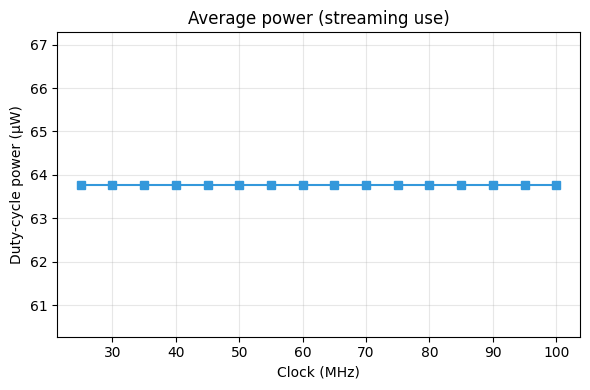

In [11]:
# Power estimates: 25–100 MHz, 5 MHz steps, with duty cycle
# Reference: Pico hardware characterization (22 nm, 50 MHz nominal, 5% switching)
DYNAMIC_50MHZ_UW = 550   # μW at 50 MHz
LEAKAGE_UW = 14          # μW (constant)
BUFFER_MS = 16           # KWS buffer period (ms between inference starts)
REF_CLOCK_MHZ = 50       # Reference clock for power scaling

# Inference cycles per frame: from m['inference_clk']/batch when available; else fallback (72,530 cycles)
batch = 1000
try:
    inference_clk = m['inference_clk'] / batch
except (NameError, KeyError, TypeError):
    inference_clk = 50_000_000 * 0.0014506
# Clock range: 25–100 MHz, step 5 MHz
clocks_mhz = np.arange(25, 101, 5)
latencies, duty_powers, active_powers, e_streaming = [], [], [], []

print(f"{'Clock':>8} {'Latency':>10} {'FPS':>10} {'Duty-cycle':>14} {'Active power':>14} {'E_streaming':>12}")
print(f"{'(MHz)':>8} {'(ms)':>10} {'':>10} {'power (μW)':>14} {'(μW)':>14} {'(μJ)':>12}")
print("-" * 72)
for f_mhz in clocks_mhz:
    f_hz = f_mhz * 1e6
    scale = f_mhz / REF_CLOCK_MHZ
    dynamic_uw = DYNAMIC_50MHZ_UW * scale
    total_uw = max(dynamic_uw + LEAKAGE_UW, LEAKAGE_UW)
    latency_ms = (inference_clk / f_hz) * 1000
    fps = f_hz / inference_clk
    duty = min(latency_ms / BUFFER_MS, 1.0)
    duty_power_uw = total_uw * duty + LEAKAGE_UW * (1 - duty)
    e_streaming_uj = duty_power_uw * (BUFFER_MS / 1000)
    latencies.append(latency_ms)
    duty_powers.append(duty_power_uw)
    active_powers.append(total_uw)
    e_streaming.append(e_streaming_uj)
    print(f"{f_mhz:>8} {latency_ms:>10.3f} {fps:>10.1f} {duty_power_uw:>14.1f} {total_uw:>14.1f} {e_streaming_uj:>12.3f}")

plot_power_estimates(clocks_mhz, np.array(duty_powers))

### Optimization: Duty cycle, power, and energy

The graphs below show how **duty cycle** drives power and energy in streaming KWS.

**Duty cycle and power:** The device is active during inference and idle (leakage only) between inferences. For real-time KWS at one inference per 16 ms buffer, average power stays **~64 μW** regardless of clock—longer active time at lower power vs. shorter active time at higher power. Energy per inference stays **~1 μJ**.

**Throughput (FPS):** The second graph shows max FPS vs clock. Stay above the required line (62.5 fps for 16 ms buffer) for real-time. If you need higher FPS than real-time, a higher clock increases power because the device spends more time active.

### Why duty-cycle power stays the same across clock speeds

The **second graph below** shows **one 16 ms buffer period** for 25 MHz and 100 MHz. The key insight:

- **Same inference = same number of cycles** regardless of clock. The hardware always does the same work.
- **25 MHz:** Hardware stays **active longer** (~2.9 ms) because cycles ÷ lower freq = longer time. Then it sits **idle** (leakage only) for the rest of the 16 ms.
- **100 MHz:** Hardware stays **active shorter** (~0.7 ms) because cycles ÷ higher freq = shorter time. Then it sits **idle** for the rest of the 16 ms.

Average power over 16 ms is the same: longer active time at lower power vs. shorter active time at higher power—the duty cycle balances out.

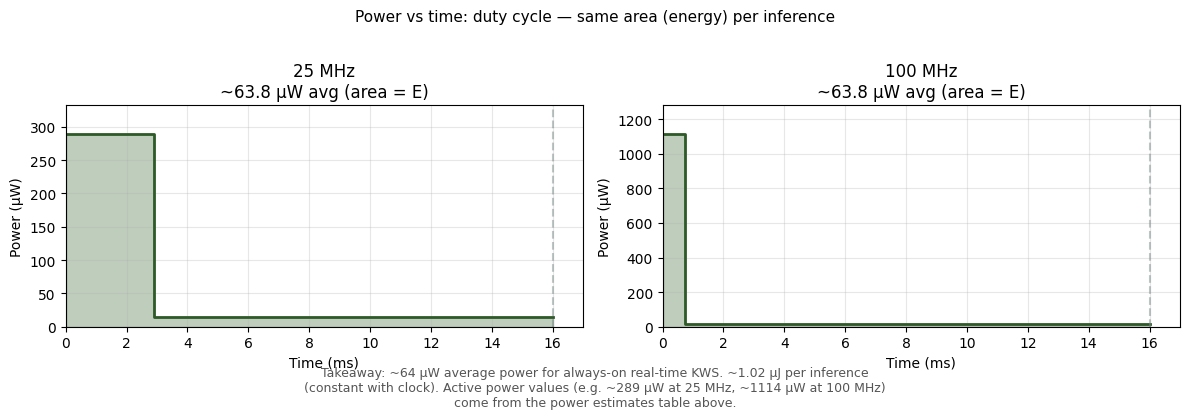

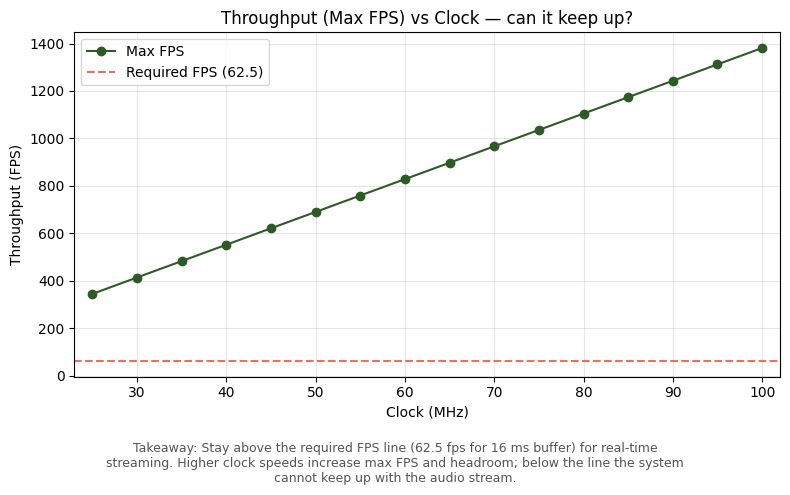

In [12]:
# Optimization: throughput and power
plot_duty_cycle_explanation(inference_clk, buffer_ms=BUFFER_MS, clocks_mhz=(25, 100),
    dynamic_50mhz_uw=DYNAMIC_50MHZ_UW, leakage_uw=LEAKAGE_UW)
plot_throughput_vs_clock(clocks_mhz, inference_clk, buffer_ms=BUFFER_MS)

### Optional: Evaluate stateful model on full test set

The cell below runs **stateful** evaluation on the full SC12 test set (loaded from TFDS). This reflects how the model performs when run in streaming mode (as on Pico).

In [13]:
from kws_utils import load_sc12_test_data, evaluate_stateful_full

# Load full SC12 test set from TFDS (already cached if you ran cell 2)
X_full, y_full = load_sc12_test_data(length=length)

# Frame-by-frame stateful eval: collect raw logits per clip, optional sliding-window smoothing.
# smooth_window=0: mean of raw logits then argmax. smooth_window=32: smooth logits then mean then argmax.
acc = evaluate_stateful_full(
    X_full, y_full, model_akida,
    length=length, timestep=timestep,
    in_akida=True,
    smooth_window=0,
    response_frames=64,
    verbose=1,
)

Evaluating stateful model on 4890 clips (312960 steps)...
Using full segment (64 frames).


Eval: 100%|██████████| 312960/312960 [03:32<00:00, 1474.51it/s]

Accuracy: 95.07%


This model is trained and evaluated on the 12-class subset (SC12) of the Google Speech Commands dataset, where each clip is a 1-second recording containing one of 10 keywords, silence, or an unknown word.

Accordingly, the notebook uses the full 1-second segment (64 feature frames) for each prediction, matching the dataset format and benchmark setup. This ensures the reported accuracy is directly reproducible.

Shorter response windows are typically used in real-time continuous-audio systems where the trigger logic decides when to fire on a keyword. Since this notebook focuses on the SC12 classification benchmark, predictions are produced over the complete 1-second segment.

## 7. Streaming inference demo

This section shows how the model behaves on a **continuous audio stream** — the same way it would run on Pico in a real application, not on isolated 1-second clips.

### What's happening (pipeline)

1. **Build a simulated stream** — We concatenate **10 SC12 clips** (1 second each) into one long waveform. This mimics a continuous feed (e.g. from a microphone).

2. **Frame-by-frame inference** — We step through the stream in **256-sample chunks** (the *timestep*). For each chunk we call `model_akida.forward(frame)`. The model's **internal state** is carried from one frame to the next, so it effectively "remembers" earlier audio within the stream.

3. **Raw logits and smoothing** — Each frame yields 12 **logits** (one per class). We store them as `preds_raw`. Optionally we apply a **sliding mean** over time and **softmax** to get smoother, more stable probabilities and reduce per-frame jitter.

4. **One prediction per clip (segment)** — To evaluate accuracy, we need one label per original 1-second clip. For each clip we **average the raw logits** over its 64 frames (`length // timestep`), then take **argmax** to get `segment_preds` — the class we assign to that segment.

5. **Graph representation** - The graph shows that the model is making **continuous, stateful decisions** as time progresses — which is exactly how it runs on Pico in real time.

### Why this matters

- **For Pico:** This demo uses the same **stateful, chunk-based** flow that runs on device: one 256-sample frame at a time, state carried forward, no need to buffer the full second. What you see here is representative of live deployment.

- **For learning:** You see the full path from raw stream → frame logits → segment predictions and how the plot reflects each step (waveform, frame-wise dots, segment labels).

In [14]:
def generate_predictions(model, input, sliding_window=64, apply_softmax=True):
    """
    Run streaming inference on a continuous input; returns raw and smoothed predictions.
    This is the core streaming logic: we step through the stream in chunks of `timestep`
    samples, run the model on each chunk (state is carried across chunks in stateful models),
    then optionally smooth the logits with a sliding mean and softmax.
    """
    in_akida = isinstance(model, akida.Model)
    if not in_akida:
        model_func = tf.function(model)

    timestep = model.input_shape[1]
    n_classes = int(model.output_shape[-1])  # SC12 has 12 classes

    preds = np.zeros((0, n_classes))
    # Ensure input is 2D (time, channels)
    if input.ndim == 1:
        input = input[:, np.newaxis]
    # Zero-pad input to the next largest multiple of timestep
    if input.shape[0] % timestep != 0:
        pad_length = timestep - (input.shape[0] % timestep)
        input = np.pad(input, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)

    # Stream: one forward pass per chunk; state is carried across chunks (stateful model)
    for tt in np.arange(0, input.shape[0], timestep):
        frame = np.expand_dims(input[tt:tt + timestep], 0).astype(np.float32)
        if in_akida:
            outs = model.forward(np.expand_dims(frame, axis=1).astype(np.int16))
        else:
            outs = model_func(tf.convert_to_tensor(frame))
        outs = np.squeeze(outs)
        if outs.ndim == 1:
            outs = outs[np.newaxis, :]
        preds = np.concatenate((preds, outs), axis=0)

    # Smooth raw logits with sliding mean (from kws_utils), then optional softmax
    if sliding_window > 0:
        class_preds = sliding_mean(preds, window_size=sliding_window)
    else:
        class_preds = preds  # no smoothing
    if apply_softmax:
        class_preds = softmax(class_preds)

    return preds, class_preds

In [15]:
# --- Streaming inference pipeline ---
# Combine first 10 test records sequentially as one continuous stream (simulating continuous audio)
N_STREAM_SAMPLES = 10
SEED = None  # set to None to get different order each run
if SEED is not None:
    np.random.seed(SEED)
# Random permutation: which samples and in what order (indices into X_test)
indices = np.random.permutation(N_STREAM_SAMPLES)
stream = np.concatenate([X_test[i] for i in indices], axis=0)  # (10*16384, 1)
labels_10 = y_test[indices]
print(f"Stream shape: {stream.shape} (={N_STREAM_SAMPLES} x {length} timepoints)")
print(f"Segment indices (order in stream): {indices}")
print(f"Ground-truth labels for the {N_STREAM_SAMPLES} segments: {y_test[indices]}")

# Use stateful recurrent model for streaming (state carries across frames)
# Optionally use model_quantized if available and compatible
# streaming_model = model_recurrent
streaming_model = model_akida
preds_raw, preds_smooth = generate_predictions(
    streaming_model, stream,
    sliding_window=0,
    apply_softmax=True
)

Stream shape: (163840, 1) (=10 x 16384 timepoints)
Segment indices (order in stream): [9 1 4 5 2 6 3 0 8 7]
Ground-truth labels for the 10 segments: [3 2 5 0 6 8 8 7 4 9]


In [16]:
# Segment-wise accuracy: each original record has 16384/256 = 64 output frames
# Use mean of RAW LOGITS (preds_raw) per segment, then argmax — not mean of softmax probs
segments_per_sample = length // timestep  # 64
segment_preds = []
for i in range(N_STREAM_SAMPLES):
    start = i * segments_per_sample
    end = (i + 1) * segments_per_sample
    # Average logits over this segment, then predict class
    seg_mean_logits = preds_raw[start:end].mean(axis=0)
    segment_preds.append(np.argmax(seg_mean_logits))
segment_preds = np.array(segment_preds)
labels_10 = labels_10[:N_STREAM_SAMPLES]
accuracy = (segment_preds == labels_10).mean() * 100
print(f"Segment predictions: {segment_preds}")
print(f"Ground truth:       {labels_10}")
print(f"Streaming accuracy (over {N_STREAM_SAMPLES} random segments): {accuracy:.2f}%")

Segment predictions: [3 2 5 0 6 8 8 7 4 9]
Ground truth:       [3 2 5 0 6 8 8 7 4 9]
Streaming accuracy (over 10 random segments): 100.00%


### Understanding the graph

The plot has **two panels**:

- **Top — "Audio stream"** — The **waveform** of the concatenated stream (amplitude vs time in ms). **Dashed vertical lines** mark the boundaries between the 10 segments. This is how the audio "comes in" to the system.


- **Bottom — "Streaming predictions"** — **Horizontal axis:** time in ms (same as the top panel). **Vertical axis:** predicted class (0–11, labeled as the 12 SC12 classes: 10 keywords + silence + unknown). Each **dot** is the model's frame-level prediction at that time. **Dot colors:** **Green** = frame-level correct (the frame's argmax prediction equals the ground truth for that segment); **light grey** = frame-level incorrect. **Dashed vertical lines** mark segment boundaries. The **text label** in the middle of each segment is the **segment prediction** (average logits over that segment → argmax), i.e. the single class we assign to that 1-second clip — this can differ from the ground truth even when many frames are green.


- **How to read it:** In a healthy run, most **green dots** in a segment should lie on the ground-truth class (correct frame-level predictions). Some **grey** dots are normal — frame-level predictions can flip briefly, so we combine them to get one stable prediction per segment (the text label). The segment label can be wrong even when many frames are green, because it comes from averaged logits over the whole segment. The graph shows that the model is making **continuous, stateful decisions** as time progresses — which is exactly how it runs on Pico in real time.

Listen: this is the continuous stream (10 keywords one after another).


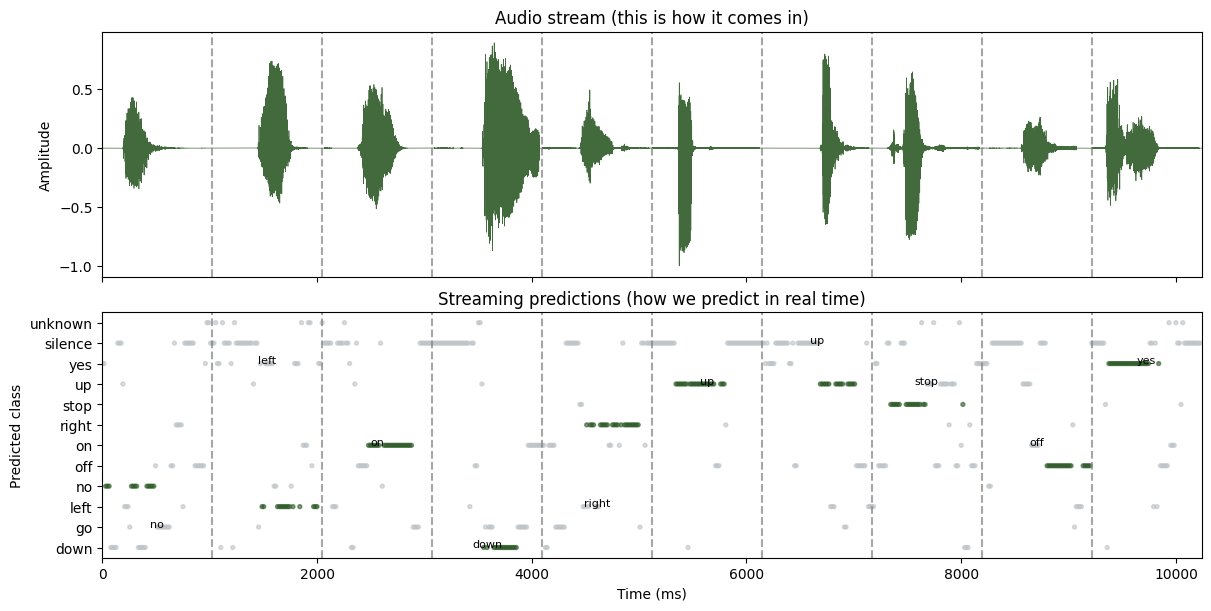

In [17]:
# --- Demo: Listen to the stream & see streaming predictions ---
# 1) Play the concatenated audio (how the stream "comes in")
# 2) Visualize waveform + predicted class over time (plotting done in kws_utils)

from IPython.display import Audio, display

# Flatten stream to 1D for playback
audio_1d = np.squeeze(stream)
# Normalize for playback if needed (Audio expects float in [-1,1] or int16)
if audio_1d.dtype == np.float32 or audio_1d.dtype == np.float64:
    if np.abs(audio_1d).max() > 1.0:
        audio_1d = audio_1d / np.abs(audio_1d).max()
else:
    audio_1d = audio_1d.astype(np.float32) / 32768.0

print("Listen: this is the continuous stream (10 keywords one after another).")
display(Audio(audio_1d, rate=SAMPLE_RATE))

# Optional: save WAV to share
# import scipy.io.wavfile
# scipy.io.wavfile.write('stream_demo.wav', SAMPLE_RATE, (audio_1d * 32767).astype(np.int16))

# Visualize: waveform + streaming predictions with segment boundaries (kws_utils)
plot_streaming_demo(
    audio_1d, preds_raw, segment_preds, labels_10,
    length, timestep, N_STREAM_SAMPLES,
    sample_rate=SAMPLE_RATE,
    label_names=LABEL_NAMES,
)

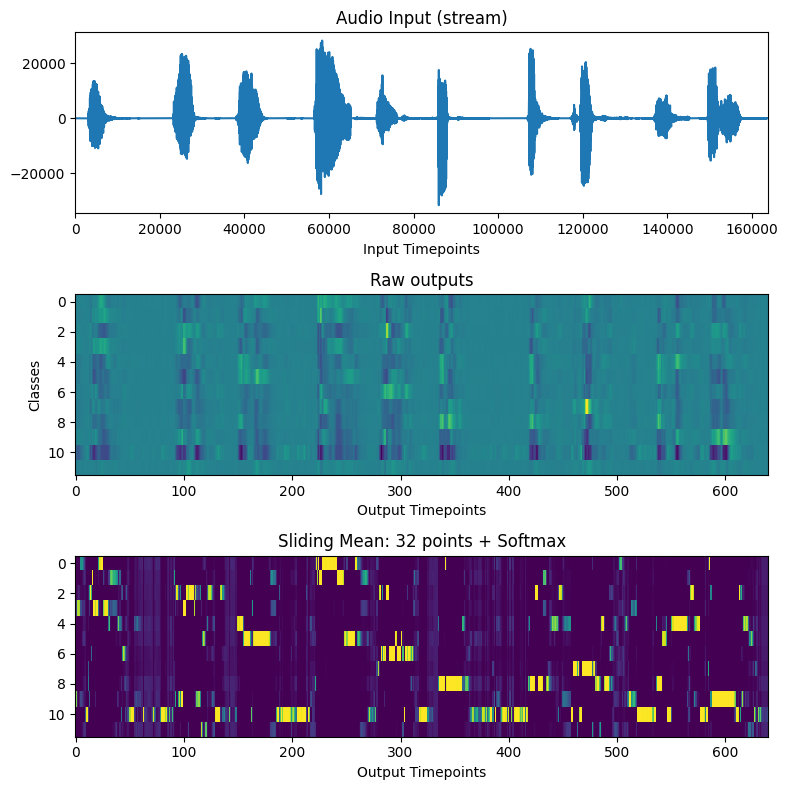

In [18]:
# Optional: debug view — raw logits and sliding-mean over time (plotting in kws_utils)
plot_streaming_debug(stream, preds_raw, preds_smooth, sliding_window=32, apply_softmax=True)